# <center><strong> Bike Rental Analysis & Prediction </strong></center>
-------------------------

#### **By Mohamed Jamyl**

http://linkedin.com/company/gray-matter-da

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

---------------------------

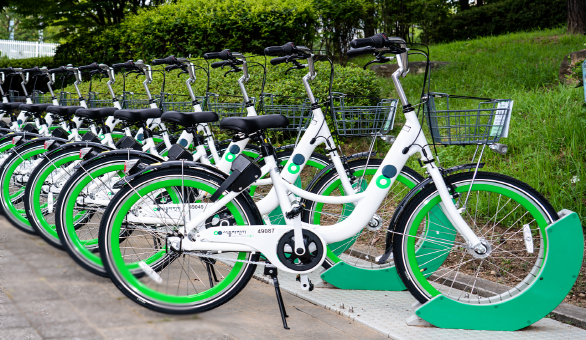

In [1]:
from IPython.display import Image
Image(filename='bi.png')

------------------------------

## <center><strong> Project Overview </strong></center>

#### **Bike share systems are a way to rent bikes where the process of obtaining membership, renting and returning bikes is automated through a network of kiosks located throughout the city. Through these systems, people can rent a bike from one location and return it to another location based on their needs. Currently, there are more than 500 bike share programs around the world.**

---------------------------------
---------------------------------
---------------------------------

## **Import Libraries** 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import calendar 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt
from pickle import dump, load


import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

----------------------------
### **Initial fonction**
------------------------------

In [3]:
def countplot(data,col):
    sns.countplot(x=col, data=data)
    plt.xlabel('Year')
    plt.show()

def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.show()

def boxplot(data, col):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(8, 4)
    sns.boxplot(data=data,x=col,orient="o",ax=axes)
    plt.show()

def boxplot2(data, x,y):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(10, 5)
    sns.boxplot(data=data,y=y,x=x,orient="v",ax=axes)
    plt.show()



----------------------------------
----------------------------------

### **Initial Data Understanding**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

----------------------

In [4]:
df = pd.read_csv("Bike rental dataset.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [5]:
df.shape

(10886, 12)

In [6]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [7]:
df.rename(columns={'casual': 'non-subscribed_users', 
                   'registered':'subscribed_users', 
                   'count': 'count_of_users', 
                   'temp':'Actual_Temperature', 
                   'atemp':'Feels_Like_Temperature'} ,inplace=True)

In [8]:
df

,datetime,season,holiday,workingday,weather,Actual_Temperature,Feels_Like_Temperature,humidity,windspeed,non-subscribed_users,subscribed_users,count_of_users
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   datetime                10886 non-null  object 
 1   season                  10886 non-null  int64  
 2   holiday                 10886 non-null  int64  
 3   workingday              10886 non-null  int64  
 4   weather                 10886 non-null  int64  
 5   Actual_Temperature      10886 non-null  float64
 6   Feels_Like_Temperature  10886 non-null  float64
 7   humidity                10886 non-null  int64  
 8   windspeed               10886 non-null  float64
 9   non-subscribed_users    10886 non-null  int64  
 10  subscribed_users        10886 non-null  int64  
 11  count_of_users          10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [10]:
df.isnull().sum()

datetime                  0
season                    0
holiday                   0
workingday                0
weather                   0
Actual_Temperature        0
Feels_Like_Temperature    0
humidity                  0
windspeed                 0
non-subscribed_users      0
subscribed_users          0
count_of_users            0
dtype: int64

In [11]:
df.duplicated().sum()

0

-----------------------
-----------------------

### **Basic Statistical Overview**

---------------------------------

- #### Summary Statistical : **describe()**

In [12]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.506614,1.116174,1.00,2.0000,3.000,4.0000,4.0000
holiday,10886.0,0.028569,0.166599,0.00,0.0000,0.000,0.0000,1.0000
workingday,10886.0,0.680875,0.466159,0.00,0.0000,1.000,1.0000,1.0000
weather,10886.0,1.418427,0.633839,1.00,1.0000,1.000,2.0000,4.0000
Actual_Temperature,10886.0,20.230860,7.791590,0.82,13.9400,20.500,26.2400,41.0000
Feels_Like_Temperature,10886.0,23.655084,8.474601,0.76,16.6650,24.240,31.0600,45.4550
humidity,10886.0,61.886460,19.245033,0.00,47.0000,62.000,77.0000,100.0000
windspeed,10886.0,12.799395,8.164537,0.00,7.0015,12.998,16.9979,56.9969
non-subscribed_users,10886.0,36.021955,49.960477,0.00,4.0000,17.000,49.0000,367.0000
subscribed_users,10886.0,155.552177,151.039033,0.00,36.0000,118.000,222.0000,886.0000


In [13]:
df.select_dtypes(include='object').describe()

,datetime
count,10886
unique,10886
top,2011-01-01 00:00:00
freq,1


-------------------------

## **Feature Extraction**

----------------------------

#### Extracting new column **[date]** from **[datetime]**

In [14]:
"2011-01-01 00:00:00".split()

['2011-01-01', '00:00:00']

In [15]:
df['datetime'][0].split()

['2011-01-01', '00:00:00']

In [16]:
df['datetime'][0].split()[0]

'2011-01-01'

In [17]:
df["date"] = df['datetime'].apply(lambda x : x.split()[0])

In [18]:
df['date'].head()

0    2011-01-01
1    2011-01-01
2    2011-01-01
3    2011-01-01
4    2011-01-01
Name: date, dtype: object

--------------------

#### Extracting new column **[time]** from **[dateime]**

In [19]:
df['datetime'][0].split()

['2011-01-01', '00:00:00']

In [20]:
df['datetime'][0].split()[1]

'00:00:00'

In [21]:
df['time'] = df['datetime'].apply(lambda x : x.split()[1])

In [22]:
df['time'].head()

0    00:00:00
1    01:00:00
2    02:00:00
3    03:00:00
4    04:00:00
Name: time, dtype: object

-------------------------------------

#### Extracting new column **[year]** from **[date]**

In [23]:
df['date'][0].split()[0]

'2011-01-01'

In [24]:
df['date'][0].split()[0].split('-')[0]

'2011'

In [25]:
df['year'] =df['date'].apply(lambda x : x.split()[0].split('-')[0])

In [26]:
df['year'].value_counts()

year
2012    5464
2011    5422
Name: count, dtype: int64

C:\Users\RPC\AppData\Local\Temp\ipykernel_17092\1817585652.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year', data=df, palette=['green','red'])


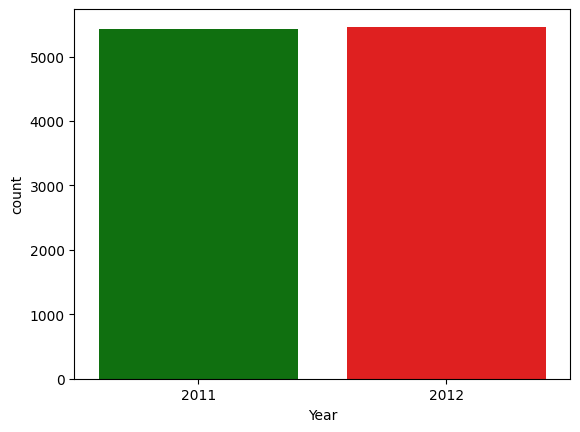

In [27]:
sns.countplot(x='year', data=df, palette=['green','red'])
plt.xlabel('Year')
plt.show()

-------------------------------

#### Extracting new column **[month]** from **[date]**

In [28]:
df['date'][0].split()[0]

'2011-01-01'

In [29]:
df['date'][0].split()[0].split('-')[1]

'01'

In [30]:
df['date'].apply(lambda x : calendar.month_name[datetime.strptime(x,"%Y-%m-%d").month])

0         January
1         January
2         January
3         January
4         January
           ...   
10881    December
10882    December
10883    December
10884    December
10885    December
Name: date, Length: 10886, dtype: object

In [31]:
df["month"] = df['date'].apply(lambda x : calendar.month_name[datetime.strptime(x,"%Y-%m-%d").month])

In [32]:
df['month'].head()

0    January
1    January
2    January
3    January
4    January
Name: month, dtype: object

In [33]:
df['month'].value_counts()

month
May          912
June         912
July         912
August       912
December     912
October      911
November     911
April        909
September    909
February     901
March        901
January      884
Name: count, dtype: int64

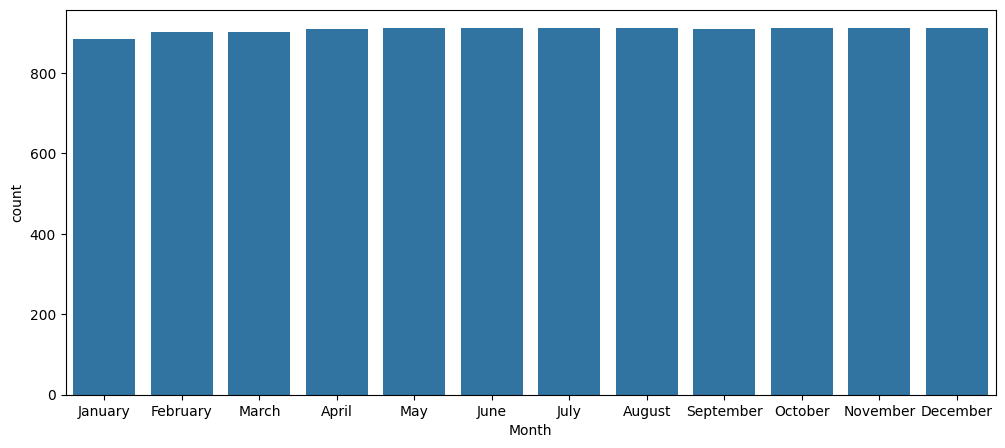

In [34]:
fig,ax= plt.subplots()
fig.set_size_inches(12,5)
sns.countplot(x='month', data=df)
plt.xlabel('Month')
plt.show()

------------------------

#### Extracting new column **[day]** from **[date]**

In [35]:
df['date'][0].split()[0]

'2011-01-01'

In [36]:
df['date'][0].split()[0].split('-')[2]

'01'

In [37]:
df['date'].apply(lambda x : calendar.day_name[datetime.strptime(x,"%Y-%m-%d").weekday()])

0         Saturday
1         Saturday
2         Saturday
3         Saturday
4         Saturday
           ...    
10881    Wednesday
10882    Wednesday
10883    Wednesday
10884    Wednesday
10885    Wednesday
Name: date, Length: 10886, dtype: object

In [38]:
df["day"] = df['date'].apply(lambda x : calendar.day_name[datetime.strptime(x,"%Y-%m-%d").weekday()])

In [39]:
df["day"].head()

0    Saturday
1    Saturday
2    Saturday
3    Saturday
4    Saturday
Name: day, dtype: object

In [40]:
df["day"].value_counts()

day
Saturday     1584
Sunday       1579
Thursday     1553
Monday       1551
Wednesday    1551
Tuesday      1539
Friday       1529
Name: count, dtype: int64

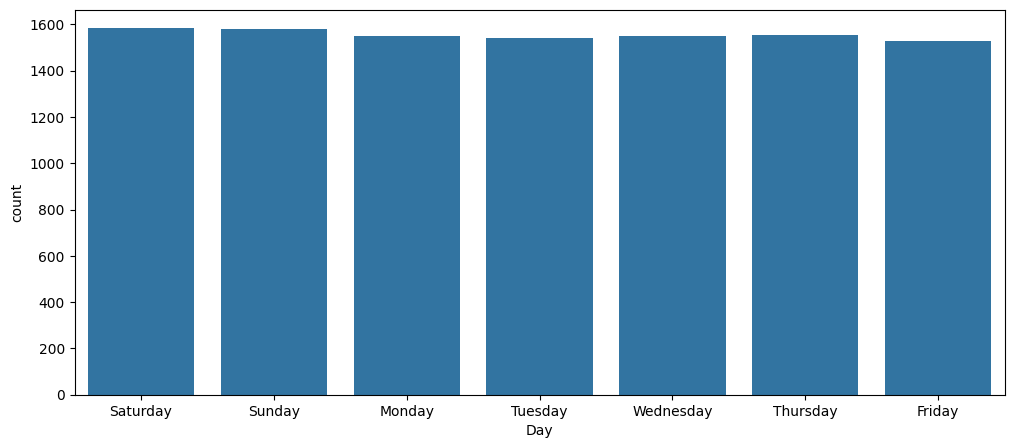

In [41]:
fig,ax= plt.subplots()
fig.set_size_inches(12,5)
sns.countplot(x='day', data=df)
plt.xlabel('Day')
plt.show()

------------------------

#### Extracting new column **[weekend]** from **[day]**

In [42]:
def WeekEnd(day):
    day = str(day)
    if day == 'Saturday' or day == 'Sunday':
        return 'Weekend'
    else:
        return 'No'

df['weekend'] = df['day'].apply(lambda x : WeekEnd(x))

In [43]:
df['weekend'].value_counts()

weekend
No         7723
Weekend    3163
Name: count, dtype: int64

C:\Users\RPC\AppData\Local\Temp\ipykernel_17092\4175082854.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weekend', data=df, palette=['green','red'])


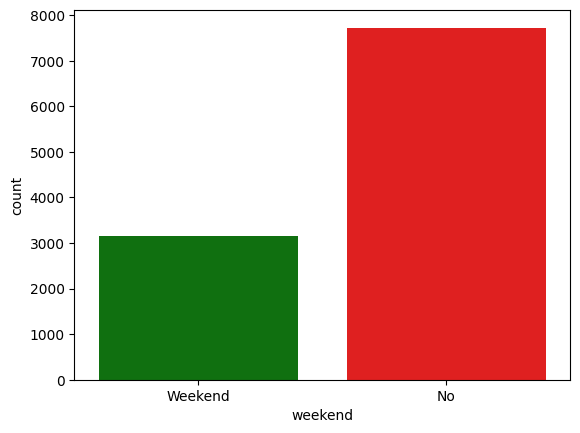

In [44]:
sns.countplot(x='weekend', data=df, palette=['green','red'])
plt.show()

------------------------

#### Extracting new column **[hour]** from **[time]**

In [45]:
df['time'][0]

'00:00:00'

In [46]:
df['time'][0].split(':')[0]

'00'

In [47]:
df['time'].apply(lambda x : x.split(":")[0])

0        00
1        01
2        02
3        03
4        04
         ..
10881    19
10882    20
10883    21
10884    22
10885    23
Name: time, Length: 10886, dtype: object

In [48]:
df["hour"] = df['time'].apply(lambda x : x.split(":")[0])

In [49]:
df['hour'].value_counts()

hour
12    456
13    456
22    456
21    456
20    456
19    456
18    456
17    456
16    456
15    456
14    456
23    456
11    455
10    455
09    455
08    455
07    455
06    455
00    455
01    454
05    452
02    448
04    442
03    433
Name: count, dtype: int64

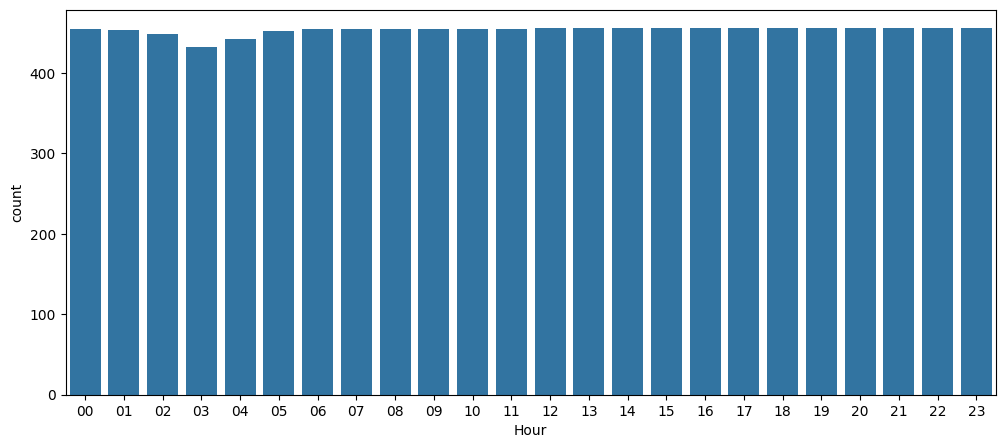

In [50]:
fig,ax= plt.subplots()
fig.set_size_inches(12,5)
sns.countplot(x='hour', data=df)
plt.xlabel('Hour')
plt.show()

------------------------

#### Extracting new column **[the_usual_time_periods_per_day]** from **[hour]**

In [51]:
df['hour'] = df['hour'].astype(int)

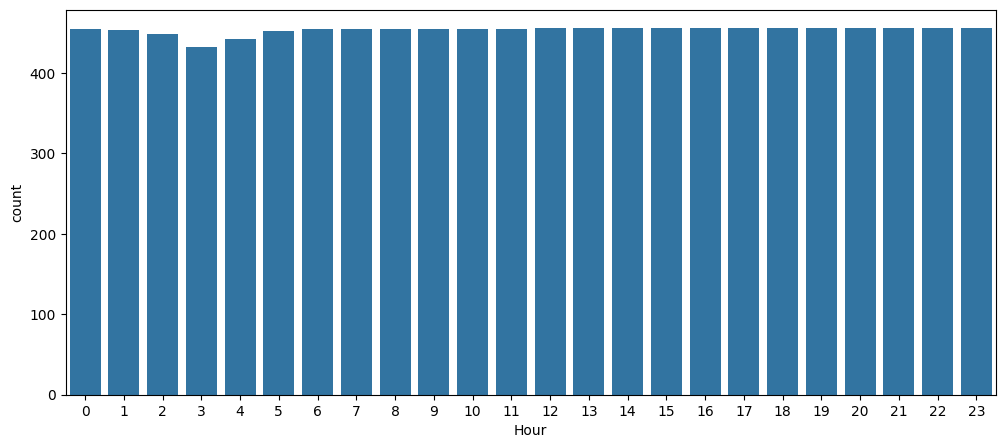

In [52]:
fig,ax= plt.subplots()
fig.set_size_inches(12,5)
sns.countplot(x='hour', data=df)
plt.xlabel('Hour')
plt.show()

In [53]:
def TheUsualTimePeriodsPerDay(hour):
    hour = int(hour)
    if 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 13:
        return 'Midday/Noon'
    elif 14 <= hour <= 17:
        return 'Afternoon'
    elif 18 <= hour <= 20:
        return 'Evening'
    elif 21 <= hour <= 23:
        return 'Night'
    else: # 0 <= hour <= 5
        return 'Midnight and After'

df['the_usual_time_periods_per_day'] = df['hour'].apply(lambda x : TheUsualTimePeriodsPerDay(x))

In [54]:
df['the_usual_time_periods_per_day'].value_counts()

the_usual_time_periods_per_day
Morning               2730
Midnight and After    2684
Afternoon             1824
Evening               1368
Night                 1368
Midday/Noon            912
Name: count, dtype: int64

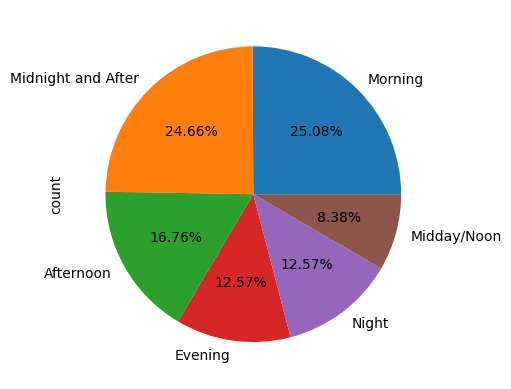

In [55]:
df['the_usual_time_periods_per_day'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

-----------------------

#### Extracting new column **[weather_feeling]** from **[Feels_Like_Temperature]**

In [56]:
df['Feels_Like_Temperature'].unique()

array([14.395, 13.635, 12.88 , 17.425, 19.695, 16.665, 21.21 , 22.725,
       21.97 , 20.455, 11.365, 10.605,  9.85 ,  8.335,  6.82 ,  5.305,
        6.06 ,  9.09 , 12.12 ,  7.575, 15.91 ,  3.03 ,  3.79 ,  4.545,
       15.15 , 18.18 , 25.   , 26.515, 27.275, 29.545, 23.485, 25.76 ,
       31.06 , 30.305, 24.24 , 18.94 , 31.82 , 32.575, 33.335, 28.79 ,
       34.85 , 35.605, 37.12 , 40.15 , 41.665, 40.91 , 39.395, 34.09 ,
       28.03 , 36.365, 37.88 , 42.425, 43.94 , 38.635,  1.515,  0.76 ,
        2.275, 43.18 , 44.695, 45.455])

In [57]:
def classify_temperature(FeelsLikeTemperature):
    
    if FeelsLikeTemperature < 0:
        return 'Freezing Cold'
    elif FeelsLikeTemperature < 11:
        return 'Cold'
    elif FeelsLikeTemperature < 21:
        return 'Cool'
    elif FeelsLikeTemperature < 26:
        return 'Mild'
    elif FeelsLikeTemperature < 31:
        return 'Warm'
    elif FeelsLikeTemperature < 36:
        return 'Hot'
    else:
        return 'Extremely Hot'

df['weather_feeling'] = df['Feels_Like_Temperature'].apply(lambda x : classify_temperature(x))

In [58]:
df['weather_feeling'].value_counts()

weather_feeling
Cool             3329
Mild             2375
Hot              2272
Warm             1539
Cold              743
Extremely Hot     628
Name: count, dtype: int64

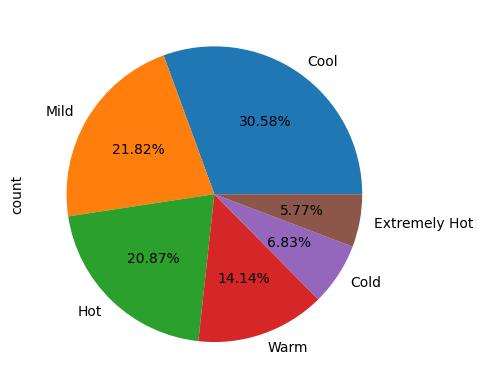

In [59]:
df['weather_feeling'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

------------------------

#### Mapping **season column**

In [60]:
df['season'].value_counts()

season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64

In [61]:
dictionnaire_saisons = {1 :"Winter" , 2: "Spring", 3 : "Summer", 4 : "Fall"}
df["season"] = df["season"].map(dictionnaire_saisons)


In [62]:
df['season'].value_counts()

season
Fall      2734
Spring    2733
Summer    2733
Winter    2686
Name: count, dtype: int64

C:\Users\RPC\AppData\Local\Temp\ipykernel_17092\3045485625.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='season', data=df, palette=['green','red','yellow','blue'])


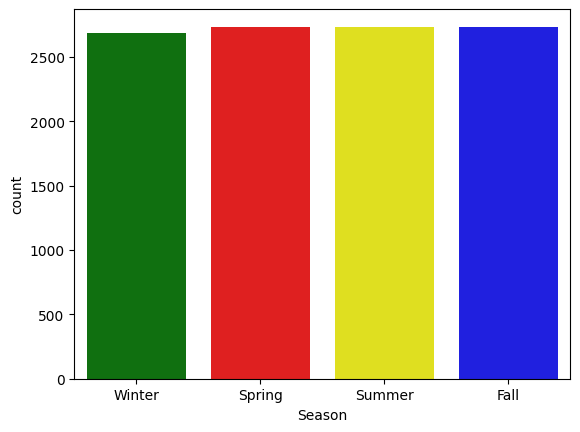

In [63]:
sns.countplot(x='season', data=df, palette=['green','red','yellow','blue'])
plt.xlabel('Season')
plt.show()

----------------------------------

#### Mapping **weather column**

##### Clear + Few clouds + Partly cloudy + Partly cloudy ----> **Clear to Partly Cloudy**
##### Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist ----> **Mist and Cloudy**
##### Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds" ----> **Light Precipitation**
##### Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog ----> **Severe Weather**

In [64]:
df["weather"].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

In [65]:
df["weather"] = df["weather"].map({1: "Clear to Partly Cloudy",\
                                        2 : "Mist and Cloudy", \
                                        3 : "Light Precipitation", \
                                        4 :"Severe Weather" })

C:\Users\RPC\AppData\Local\Temp\ipykernel_17092\1604790228.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weather', data=df, palette=['green','red','yellow','blue'])


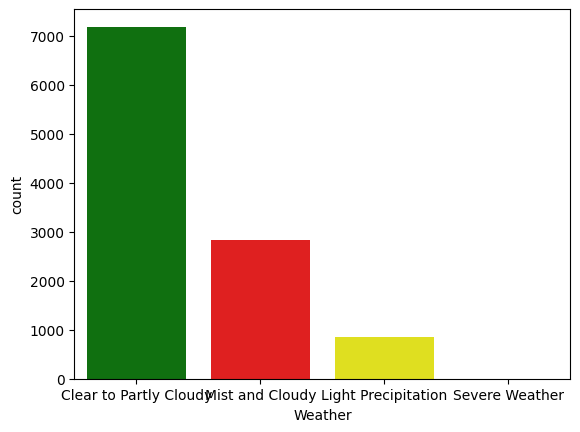

In [66]:
sns.countplot(x='weather', data=df, palette=['green','red','yellow','blue'])
plt.xlabel('Weather')
plt.show()

----------------------------------
#### Mapping **holiday column**

In [67]:
df["holiday"] = df["holiday"].map({0: "no", 1: "yes"})

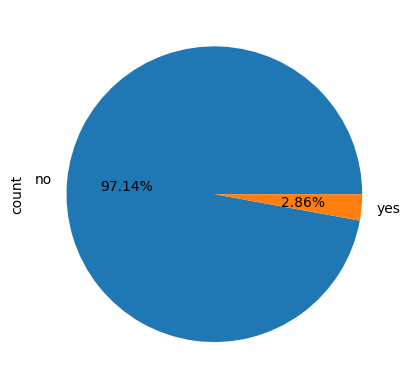

In [68]:
pie(df,'holiday')

------------------------------------
## **EDA**
------------------------------------

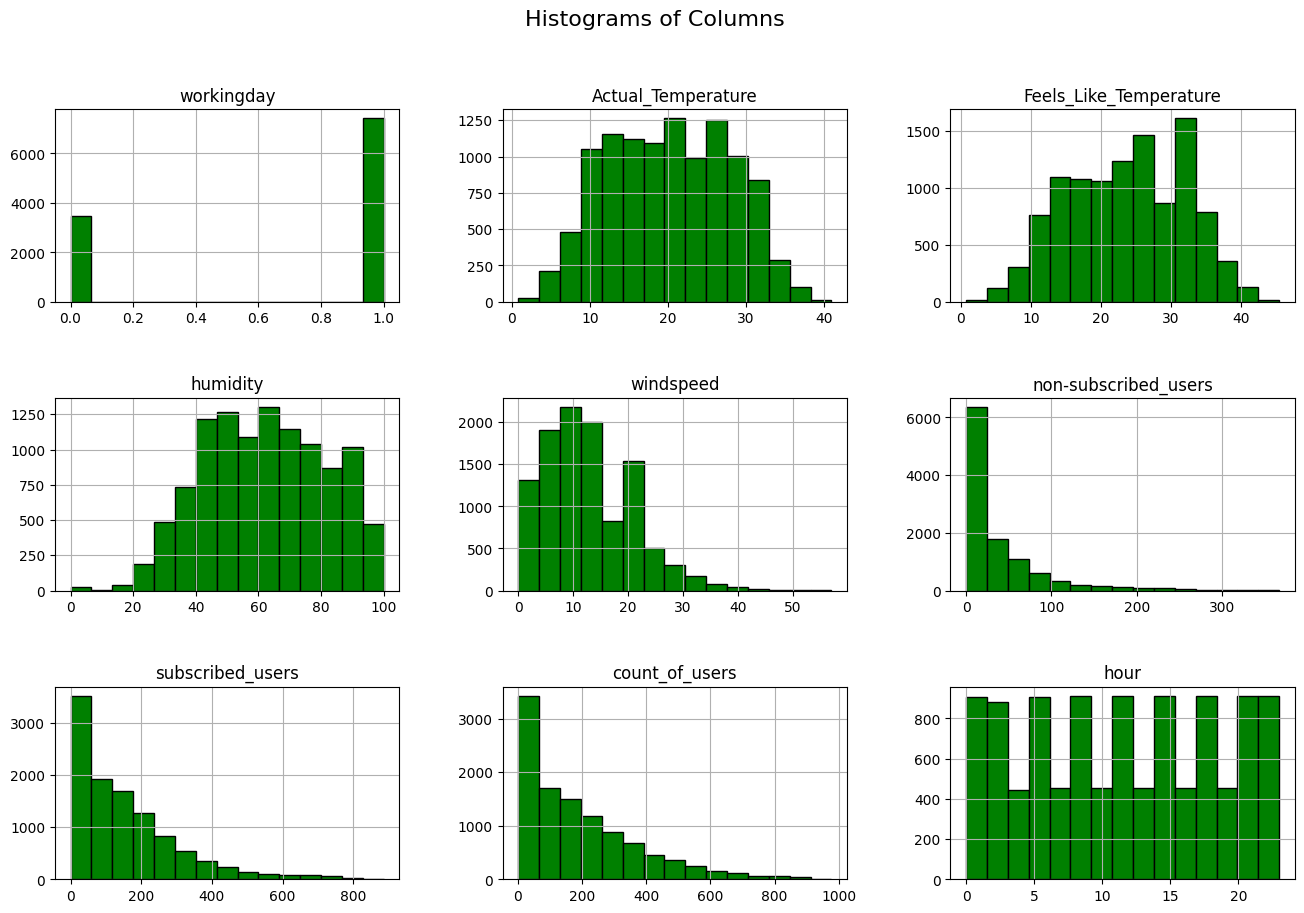

In [69]:
df.select_dtypes('number').hist(bins=15, figsize=(16, 10), color='green', edgecolor='black')

plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5) 
plt.show()

- ### **Correlation**

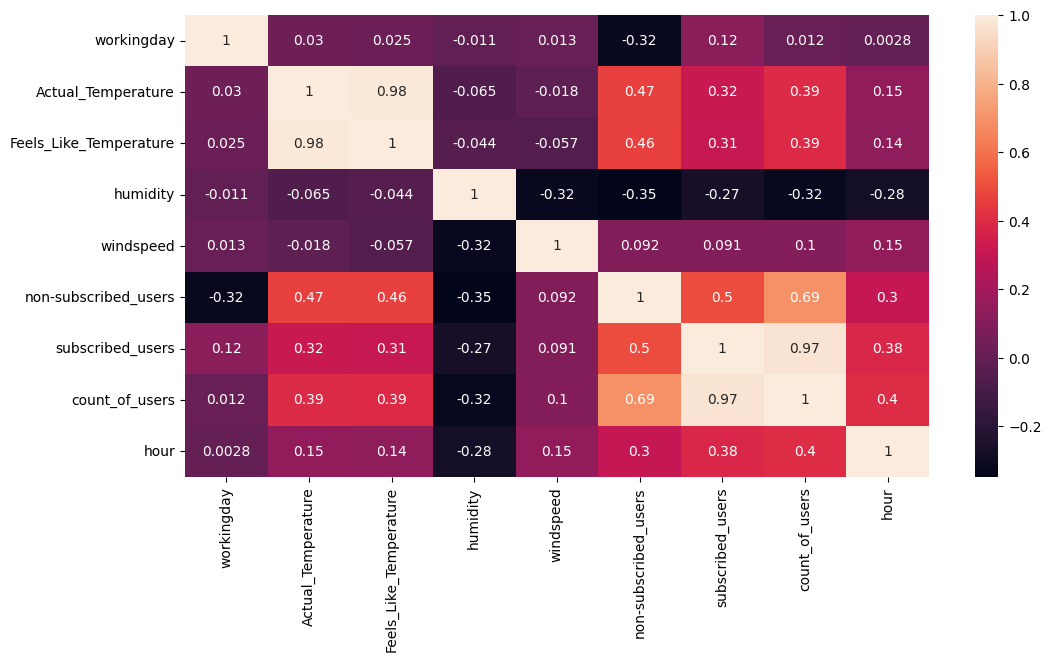

In [70]:
plt.figure(figsize=(12,	6))
sns.heatmap(df.select_dtypes('number').corr(), annot=True)
plt.show()

#### **1. Customer Types and Pricing Plan (User Types vs. Working Days)**
##### There is a moderate negative correlation (-0.32) between working days and non-subscribe users, compared to a positive correlation (0.12) with subscribes users.

##### Business Interpretation : Members rely on bicycles as a primary and economical means of transportation to work and university. non-subscribe users (tourists and leisure travelers) avoid the financially draining traffic of workdays (based on hourly rates) and prefer recreational rentals on weekends and holidays.

#### **2. Weather Impact:**
##### Temperature is the biggest driver of occupancy rates, and its correlation with the non-subscribe users (0.47) is stronger than with the subscribe users (0.32).

##### Business Interpretation : The leisure user is very sensitive to weather conditions and will only rent during warm weather (spring and summer), while the subscribe users is obligated to stay even on cold days due to work requirements. A logical inverse correlation (-0.32) was also observed between humidity and wind speed.

#### **3. Hourly Demand Dynamics**
##### There is a general positive correlation (0.4) between the hours of the day and the number of users.

##### Business Interpretation : Demand is negligible in the early morning hours (1 to 5 AM) because most users are asleep, and it gradually increases as the day progresses. (The relationship here is non-linear and follows the morning and evening peak demand curves.)

- ### **Count of users Distribution**

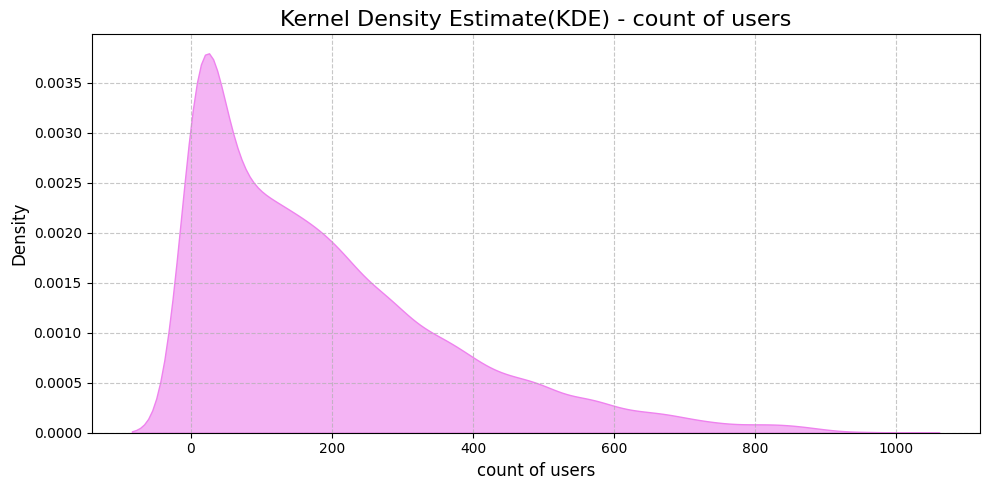

In [71]:
plt.figure(figsize=(10,	5))
sns.kdeplot(df['count_of_users'], fill=True,	color='violet', alpha=0.6)
plt.title(f'Kernel Density Estimate(KDE) - count of users',	fontsize=16)
plt.xlabel('count of users', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### This distribution tells us that our business is generally stable at low to medium rates most of the time (the large pink block on the left), but we do have 'explosive peak seasons' (the long tail extending to the right towards 600 and 800 users). These peaks don't always occur, but when they do, they pull the company's overall average up.


- ### **boxplot of count of users**


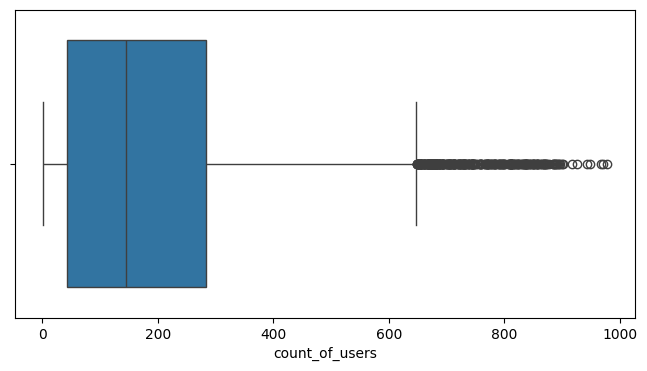

In [72]:
boxplot(df,'count_of_users')


- ### **boxplot of count of users vs categorical features**


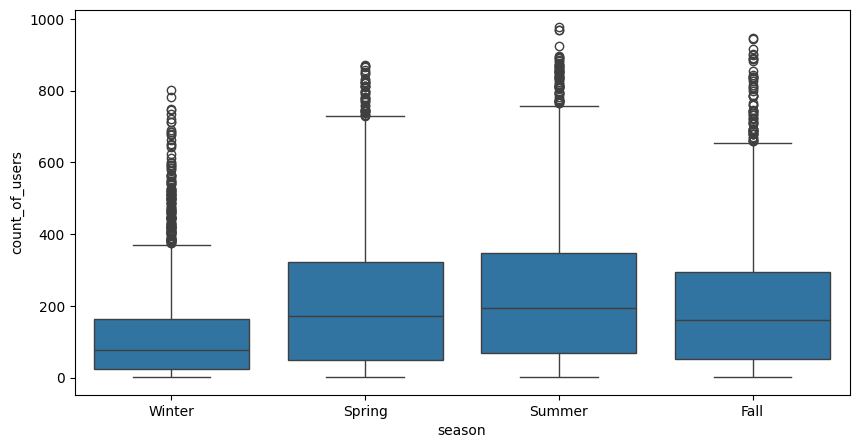

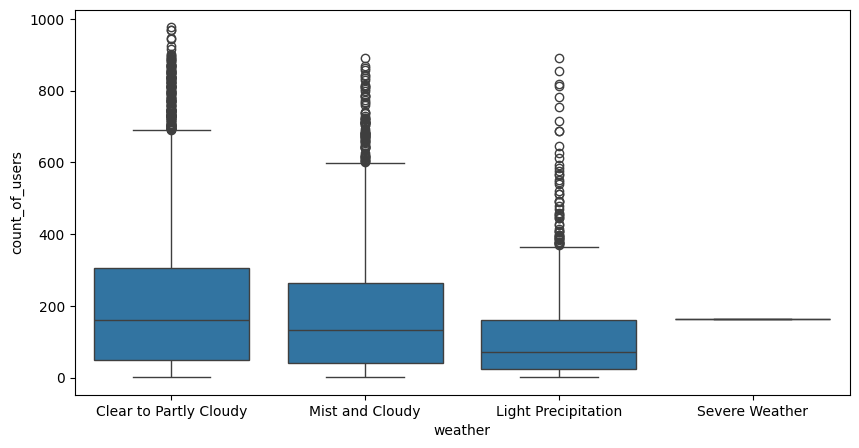

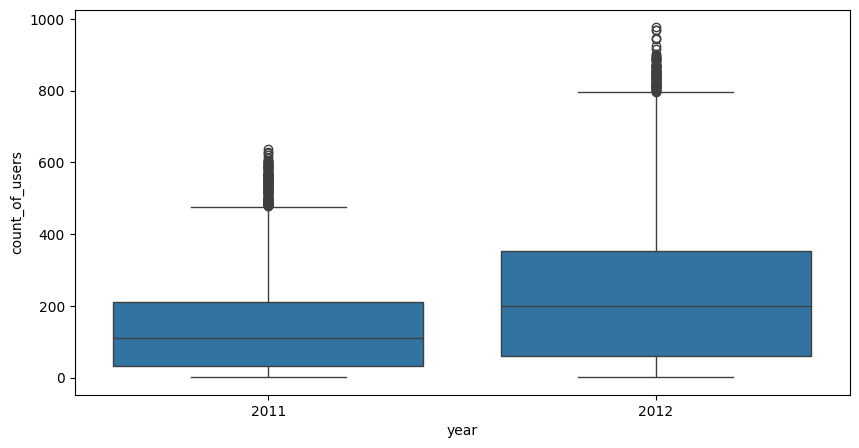

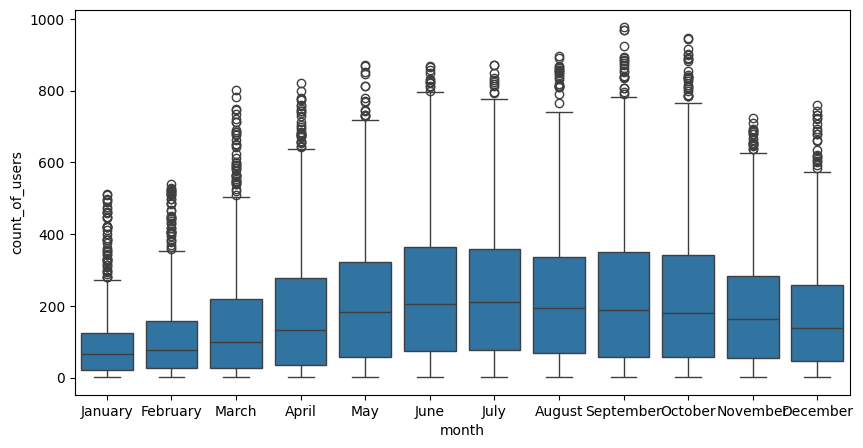

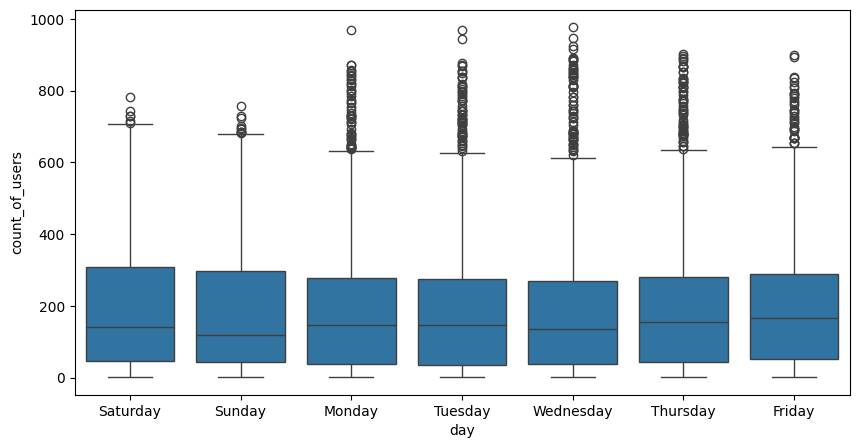

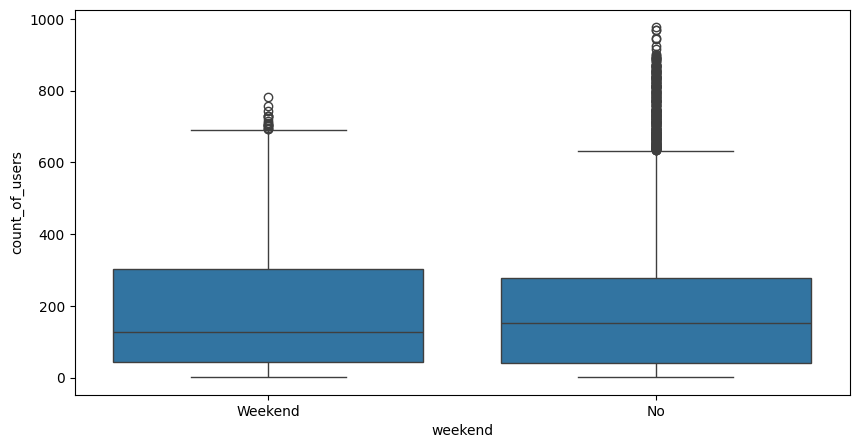

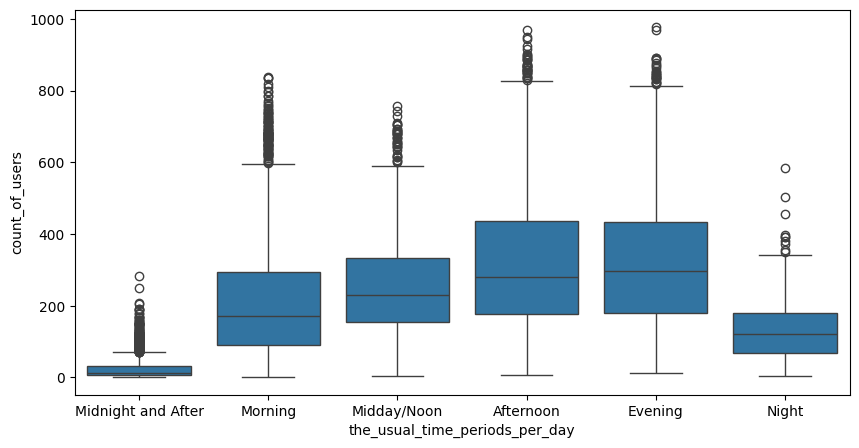

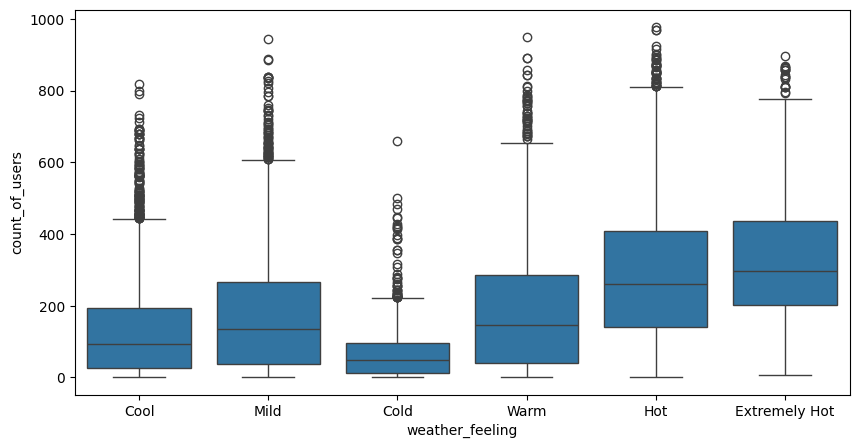

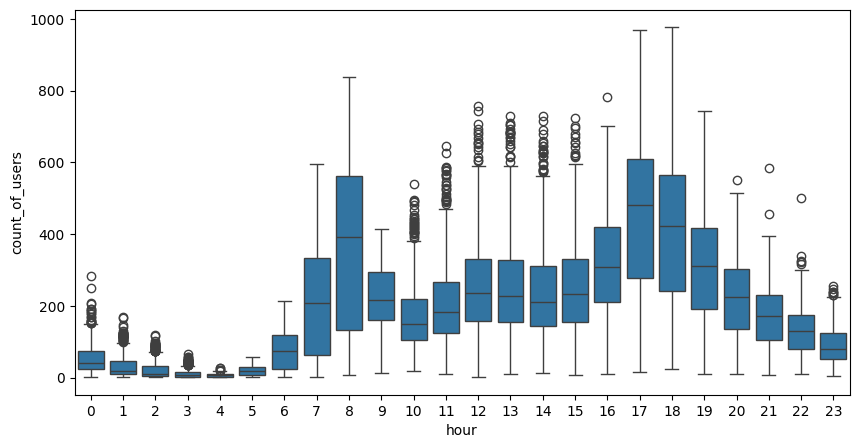

In [73]:
colscat = ['season','weather','year', 'month', 'day','weekend', 'the_usual_time_periods_per_day', 'weather_feeling','hour']
for col in colscat:
    boxplot2(df,col,'count_of_users')

-----------------------

In [ ]:
# df.to_excel('Bake rental (New data).xlsx',index=False)

--------------------------------
------------------------------

## **Analysis**

--------------------------------

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,Actual_Temperature,Feels_Like_Temperature,humidity,windspeed,non-subscribed_users,...,count_of_users,date,time,year,month,day,weekend,hour,the_usual_time_periods_per_day,weather_feeling
0,2011-01-01 00:00:00,Winter,0,0,Clear to Partly Cloudy,9.84,14.395,81,0.0,3,...,16,2011-01-01,00:00:00,2011,January,Saturday,Weekend,0,Midnight and After,Cool
1,2011-01-01 01:00:00,Winter,0,0,Clear to Partly Cloudy,9.02,13.635,80,0.0,8,...,40,2011-01-01,01:00:00,2011,January,Saturday,Weekend,1,Midnight and After,Cool
2,2011-01-01 02:00:00,Winter,0,0,Clear to Partly Cloudy,9.02,13.635,80,0.0,5,...,32,2011-01-01,02:00:00,2011,January,Saturday,Weekend,2,Midnight and After,Cool
3,2011-01-01 03:00:00,Winter,0,0,Clear to Partly Cloudy,9.84,14.395,75,0.0,3,...,13,2011-01-01,03:00:00,2011,January,Saturday,Weekend,3,Midnight and After,Cool
4,2011-01-01 04:00:00,Winter,0,0,Clear to Partly Cloudy,9.84,14.395,75,0.0,0,...,1,2011-01-01,04:00:00,2011,January,Saturday,Weekend,4,Midnight and After,Cool


-----------------------

##### **Months groub by mean of count of users**

In [ ]:
sortOrder = ["January","February","March","April","May","June","July","August","September","October","November","December"]
hueOrder = ["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]

monthAggregated = DataFrame(df.groupby("month")["count_of_users"].mean()).reset_index()

In [ ]:
monthAggregated

,month,count_of_users
0,April,167.282633
1,August,209.696101
2,December,167.947720
3,February,110.003330
4,January,90.366516
5,July,219.409040
6,June,218.017241
7,March,138.040678
8,May,202.437146
9,November,185.039106


C:\Users\RPC\AppData\Local\Temp\ipykernel_21392\2799023441.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot(data=monthAggregated, x="month", y="count_of_users", ax=ax, order=sortOrder, palette="viridis")


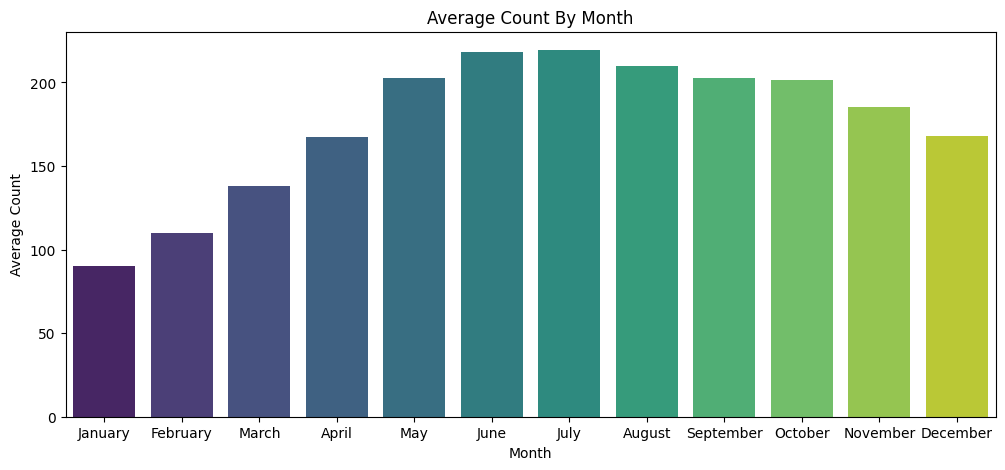

In [ ]:
fig, ax = subplots()
fig.set_size_inches(12, 5)

barplot(data=monthAggregated, x="month", y="count_of_users", ax=ax, order=sortOrder, palette="viridis")
ax.set(xlabel='Month', ylabel='Average Count', title="Average Count By Month")
show()

- ##### **Clear Seasonal Pattern**: There's a very distinct seasonal pattern in the average count.

- ##### **Lowest Counts in Winter**: January has the lowest average count, followed by February.

- ##### **Gradual Increase in Spring**: The average count steadily increases from March through April and May.

- ##### **Peak in Summer**: June and July show the highest average counts, indicating peak activity during these summer months. August also maintains a high average count.

- ##### **Decline in Fall/Winter**: The average count begins to decline from September through October, November, and December, returning to lower levels as winter approaches.

- ##### **Color Gradient**: The bars are colored with a gradient, visually reinforcing the trend from lower counts (darker purple/blue) to higher counts (greens/teals) and back to lower (yellow-green).

-------------------

##### **Hours and season groub by mean of count of users**

In [ ]:
hourAggregated = DataFrame(df.groupby(["hour","season"], sort=True)["count_of_users"].mean()).reset_index()
hourAggregated

,hour,season,count_of_users
0,0,Fall,57.877193
1,0,Spring,58.473684
2,0,Summer,75.675439
3,0,Winter,28.292035
4,1,Fall,36.166667
...,...,...,...
91,22,Winter,72.912281
92,23,Fall,89.298246
93,23,Spring,101.684211
94,23,Summer,121.719298


C:\Users\RPC\AppData\Local\Temp\ipykernel_21392\2794846622.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["season"], data=hourAggregated, join=True,ax=ax)


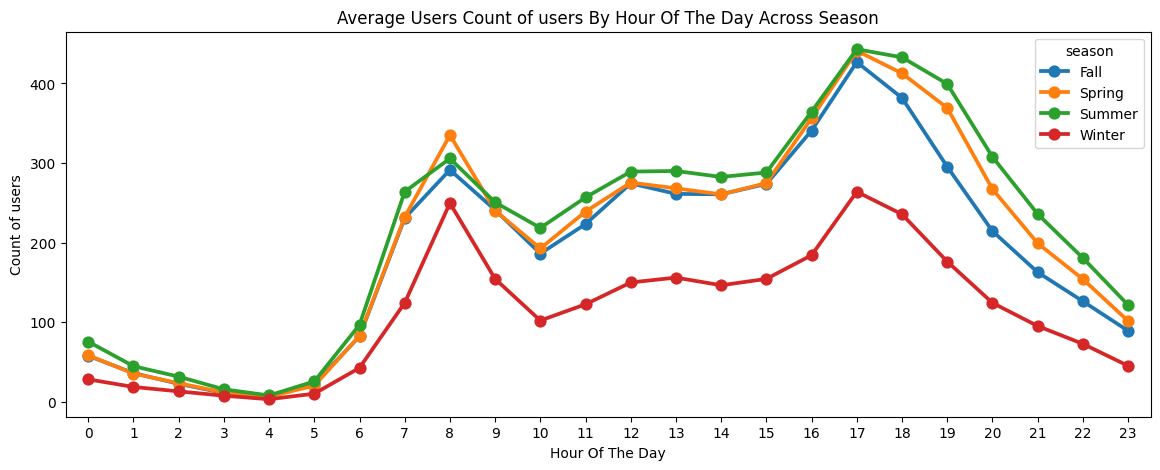

In [ ]:
fig,ax= subplots()
fig.set_size_inches(14,5)
pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["season"], data=hourAggregated, join=True,ax=ax)
ax.set(xlabel='Hour Of The Day', ylabel='Count of users',title="Average Users Count of users By Hour Of The Day Across Season",label='big')
show()

- ##### **Clear Daily and Seasonal Patterns:** The plot clearly shows distinct daily cycles of user activity, with significant differences between seasons.

- ##### **Two Peaks in User Activity**: For most seasons, there appear to be two main peaks in user activity: one in the morning/late morning and another, more prominent, in the late afternoon/early evening.

- ##### **Lowest Activity in Early Morning**: User counts are consistently lowest across all seasons in the very early morning hours (approximately 1 AM to 5 AM).

#### **Season-Specific Patterns**:

- #### **Summer (Green Line)**:

- ##### Generally shows the highest average user counts throughout the day, especially during peak hours.

- ##### Morning peak is around 8 AM (over 300 users).

- ##### Evening peak is the highest of all seasons, reaching over 400 users around 5 PM - 6 PM (17:00-18:00).

- ##### Maintains high activity levels for a longer duration during the day.

- #### **Spring (Orange Line)**:

- ##### Follows a very similar pattern to Summer, often just slightly below Summer's counts.

- ##### Morning peak around 8 AM (around 300 users).

- ##### Evening peak around 5 PM - 6 PM (17:00-18:00), also very high (close to 400 users).

- #### Fall (Blue Line):

- ##### Shows a similar daily pattern to Spring and Summer but with slightly lower average counts overall, particularly during the evening peak.

- ##### Morning peak around 8 AM (around 290 users).

- ##### Evening peak around 5 PM - 6 PM (17:00-18:00), reaching around 380-390 users.

- #### Winter (Red Line):

- ##### Consistently shows the lowest average user counts throughout the day compared to other seasons.

- ##### Morning peak is lower, around 8 AM (around 250 users).

- ##### Evening peak is also significantly lower, around 5 PM - 6 PM (17:00-18:00), reaching around 260-270 users.

- ##### The overall curve is flatter, indicating less extreme fluctuations in user activity compared to warmer seasons.

-------------------------

##### **Hours and days groub by mean of count of users**

In [ ]:
hourAggregated = DataFrame(df.groupby(["hour","day"],sort=True)["count_of_users"].mean()).reset_index()
hourAggregated

,hour,day,count_of_users
0,0,Friday,53.234375
1,0,Monday,35.492308
2,0,Saturday,98.212121
3,0,Sunday,96.227273
4,0,Thursday,37.476923
...,...,...,...
163,23,Saturday,120.030303
164,23,Sunday,64.757576
165,23,Thursday,99.630769
166,23,Tuesday,76.061538


C:\Users\RPC\AppData\Local\Temp\ipykernel_21392\2714275970.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["day"],hue_order=hueOrder, data=hourAggregated, join=True,ax=ax)


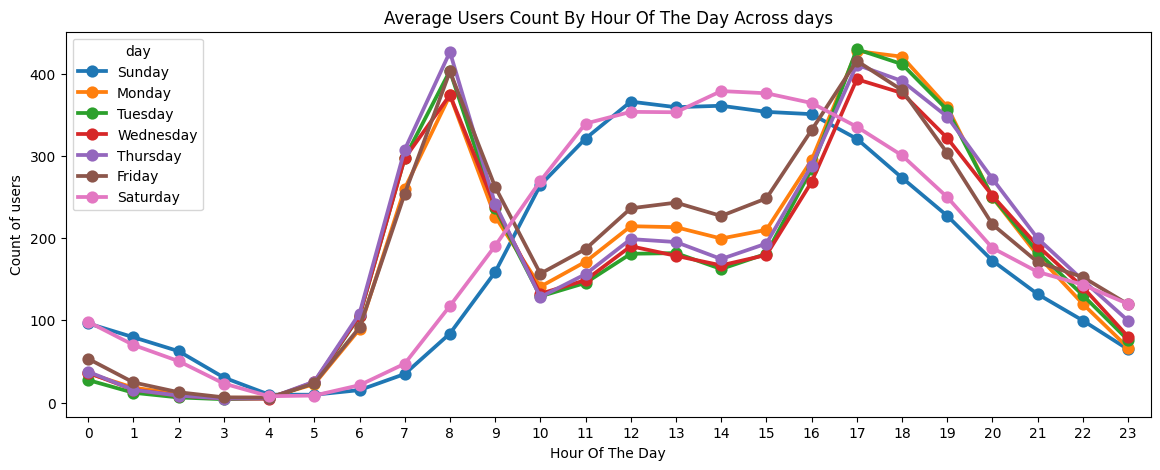

In [ ]:
fig,ax= subplots()
fig.set_size_inches(14,5)

pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["day"],hue_order=hueOrder, data=hourAggregated, join=True,ax=ax)
ax.set(xlabel='Hour Of The Day', ylabel='Count of users',title="Average Users Count By Hour Of The Day Across days",label='big')
show()

- ##### **Clear Daily Cycles**: All days exhibit a distinct daily cycle of user activity, with lows in the early morning and peaks during the day.

- ##### **Weekend vs. Weekday Patterns**: There are noticeable differences between weekend (Saturday, Sunday) and weekday (Monday-Friday) patterns.

- ##### **Early Morning Lows**: User counts are consistently very low across all days in the early morning hours (approximately 1 AM to 5 AM).

### Day-Specific Patterns:

- ##### **Weekdays (Monday-Friday)**:

- ##### **Morning Peak**: Most weekdays show a prominent morning peak around 8 AM - 9 AM. This is likely associated with the start of the workday/school day. Thursday and Friday's morning peaks are slightly lower than Monday-Wednesday.

- ##### **Mid-day Dip**: After the morning peak, there's a noticeable dip in user counts during late morning/early afternoon (around 9 AM - 3 PM).

- ##### **Evening Peak**: All weekdays show a strong evening peak, typically around 5 PM - 7 PM (17:00-19:00). This peak is generally higher than the morning peak. Tuesday and Wednesday often show the highest evening peaks among weekdays, reaching over 400 users.

- ##### **Decline**: User counts gradually decline from the evening peak into the late night.

### Weekends (Saturday & Sunday):

- ##### **Delayed Morning Activity**: Activity starts later in the morning compared to weekdays. The sharp rise in users begins around 7 AM - 8 AM, rather than 6 AM.

- ##### **Single, Broader Peak**: Instead of distinct morning and evening peaks, weekends tend to have a single, broader peak of activity that spans from late morning through the afternoon.

- ##### **Saturday**: Shows a strong, sustained high level of activity from around 10 AM to 6 PM (18:00), with a peak around 1 PM - 2 PM (13:00-14:00). The overall activity level is often lower than weekday evening peaks but higher than weekday mid-day dips.

- ##### **Sunday**: Similar to Saturday, with a broad peak, but often with slightly lower overall counts than Saturday, especially in the afternoon.

### Key Differences Summarized:

- ##### **Weekday**: Characterized by two distinct peaks (morning and evening), with a mid-day dip. The evening peak is usually the highest.

- ##### **Weekend**: Characterized by a later start to activity and a single, broader peak spanning the afternoon.

------------------------

##### **Hours groub by mean of subscribed users + non-subscribed users**

In [ ]:
hourTransformed = melt(df[["hour","non-subscribed_users","subscribed_users"]], id_vars=['hour'], value_vars=['non-subscribed_users', 'subscribed_users'])
hourAggregated = DataFrame(hourTransformed.groupby(["hour","variable"],sort=True)["value"].mean()).reset_index()
hourAggregated.head()

,hour,variable,value
0,0,non-subscribed_users,10.312088
1,0,subscribed_users,44.826374
2,1,non-subscribed_users,6.513216
3,1,subscribed_users,27.345815
4,2,non-subscribed_users,4.819196


C:\Users\RPC\AppData\Local\Temp\ipykernel_21392\1769763816.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  pointplot(x=hourAggregated["hour"], y=hourAggregated["value"],hue=hourAggregated["variable"],hue_order=["non-subscribed_users","subscribed_users"], data=hourAggregated, join=True,ax=ax)


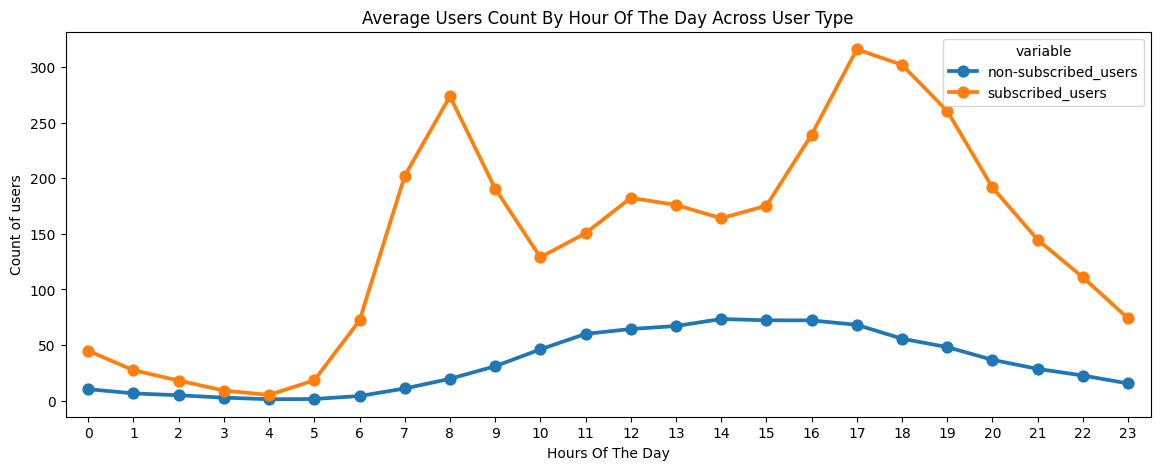

In [ ]:
fig,ax= subplots()
fig.set_size_inches(14,5)

pointplot(x=hourAggregated["hour"], y=hourAggregated["value"],hue=hourAggregated["variable"],hue_order=["non-subscribed_users","subscribed_users"], data=hourAggregated, join=True,ax=ax)
ax.set(xlabel='Hours Of The Day', ylabel='Count of users',title="Average Users Count By Hour Of The Day Across User Type",label='big')
show()

### Subscribed Users Dominate Total Count:

- ##### The 'subscribed_users' (orange line) consistently show a significantly higher average count at almost all hours compared to 'non-subscribed_users' (blue line). This indicates that the majority of the overall user activity is driven by subscribed users.

- #### **Distinct Daily Patterns for Each User Type:**

- ##### **Non-subscribed Users (Blue Line)**:

- ##### Low Activity in Early Morning: Very low counts from 0 to 5 AM.

- ##### Gradual Increase: A slow, steady increase in average count from around 6 AM, peaking in the afternoon/early evening (around 3 PM - 5 PM / 15:00-17:00), reaching an average of about 70-75 users.

- ##### Slow Decline: A gradual decline in counts through the late evening.

- ##### The curve is relatively flat and does not show sharp peaks, suggesting a more consistent, less volatile activity pattern.

- #### Subscribed Users (Orange Line):

- ##### Low Activity in Early Morning: Similar to non-subscribed users, very low counts from 0 to 5 AM.

- ##### Sharp Morning Peak: A rapid increase in activity starting around 6 AM, leading to a prominent morning peak around 8 AM (over 270 users). This suggests a strong morning rush for subscribed users.

- ##### Mid-day Dip: A noticeable dip in activity after the morning peak (around 9 AM - 10 AM).

- ##### gher Evening Peak: Activity rises again, reaching an even higher evening peak around 5 PM - 6 PM (17:00-18:00), exceeding 300 users. This is the highest point of activity for subscribed users.

- ##### Steep Decline: A relatively steep decline in counts through the late evening.

### **Comparison and Interpretation**:

- ##### Peak Times: Subscribed users exhibit two distinct peaks (morning and evening), which align with typical workday hours, suggesting they might be using the service for work-related or routine activities. Non-subscribed users have a single, broader, and much lower peak in the afternoon.

- ##### Magnitude of Activity: Subscribed users contribute far more to the overall user count at any given hour.

- ##### Behavioral Differences: The differing patterns suggest distinct behavioral characteristics between the two user types. Subscribed users show more structured, perhaps routine-driven, engagement, while non-subscribed users have a flatter, lower-level activity profile.

---------------------------------
--------------------------------

## **Transform data**

-----------------------

In [ ]:
# Remove some columns
df = df.drop(['datetime', "date", 'time', 'non-subscribed_users', 'subscribed_users'], axis=1)

In [ ]:
df['year'] = df['year'].astype(int)

In [ ]:
object_data = df.select_dtypes('object')
non_object_data = df.select_dtypes('number')

In [ ]:
object_data

,season,weather,month,day,weekend,the_usual_time_periods_per_day,weather_feeling
0,Winter,Clear to Partly Cloudy,January,Saturday,Weekend,Midnight and After,Cool
1,Winter,Clear to Partly Cloudy,January,Saturday,Weekend,Midnight and After,Cool
2,Winter,Clear to Partly Cloudy,January,Saturday,Weekend,Midnight and After,Cool
3,Winter,Clear to Partly Cloudy,January,Saturday,Weekend,Midnight and After,Cool
4,Winter,Clear to Partly Cloudy,January,Saturday,Weekend,Midnight and After,Cool
...,...,...,...,...,...,...,...
10881,Fall,Clear to Partly Cloudy,December,Wednesday,No,Evening,Cool
10882,Fall,Clear to Partly Cloudy,December,Wednesday,No,Evening,Cool
10883,Fall,Clear to Partly Cloudy,December,Wednesday,No,Night,Cool
10884,Fall,Clear to Partly Cloudy,December,Wednesday,No,Night,Cool


-------------------------------

In [ ]:
object_data['weekend'].unique()

array(['Weekend', 'No'], dtype=object)

In [ ]:
object_data['weekend'] = object_data['weekend'].map({'No':0, 'Weekend':1})

In [ ]:
object_data['weekend'].value_counts()

weekend
0    7470
1    3116
Name: count, dtype: int64

------------------------

In [ ]:
object_data['weather'].unique()

array(['Clear to Partly Cloudy', 'Mist and Cloudy', 'Light Precipitation',
       'Severe Weather'], dtype=object)

In [ ]:
object_data['weather']= object_data['weather'].map({'Clear to Partly Cloudy':0,'Mist and Cloudy':1,'Light Precipitation':2,'Severe Weather':3})

In [ ]:
object_data['weather'].value_counts()

weather
0    6965
1    2770
2     850
3       1
Name: count, dtype: int64

--------------------------

In [ ]:
object_data['weather_feeling'].unique()

array(['Cool', 'Mild', 'Cold', 'Warm', 'Hot', 'Extremely Hot'],
      dtype=object)

In [ ]:
object_data['weather_feeling']= object_data['weather_feeling'].map({'Cold':0, 'Cool':1, 'Mild':2,'Warm':3,'Hot':4,'Extremely Hot':5})

In [ ]:
object_data['weather_feeling'].value_counts()

weather_feeling
1    3307
2    2331
4    2127
3    1490
0     742
5     589
Name: count, dtype: int64

-------------------------------

In [ ]:
object_data['month'].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

In [ ]:
object_data['month']= object_data['month'].map({'January':1, 'February':2,'March':3,'April':4, 'May':5, 'June':6, 'July':7,
                                                'August':8, 'September':9, 'October':10, 'November':11, 'December':12})

In [ ]:
object_data['month'].value_counts()

month
2     901
12    899
11    895
3     885
7     885
1     884
5     883
4     881
8     872
10    871
6     870
9     860
Name: count, dtype: int64

-------------------------------

In [ ]:
object_data['day'].unique()

array(['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday',
       'Friday'], dtype=object)

In [ ]:
object_data['day']= object_data['day'].map({'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4, 'Saturday':5, 'Sunday':6})

In [ ]:
object_data['day'].value_counts()

day
6    1563
5    1553
0    1509
3    1494
2    1492
4    1491
1    1484
Name: count, dtype: int64

------------------------------

In [ ]:
object_data['season'].unique()

array(['Winter', 'Spring', 'Summer', 'Fall'], dtype=object)

In [ ]:
object_data['season']= object_data['season'].map({'Winter':0, 'Spring':1, 'Summer':2, 'Fall':3})

In [ ]:
object_data['season'].value_counts()

season
0    2670
3    2665
1    2634
2    2617
Name: count, dtype: int64

------------------------

In [ ]:
object_data['the_usual_time_periods_per_day'].unique()

array(['Midnight and After', 'Morning', 'Midday/Noon', 'Afternoon',
       'Evening', 'Night'], dtype=object)

In [ ]:
object_data['the_usual_time_periods_per_day']= object_data['the_usual_time_periods_per_day'].map({'Midnight and After':0, 'Morning':1,
                            'Midday/Noon':2, 'Afternoon':3, 'Evening':4, 'Night':5})

In [ ]:
object_data['the_usual_time_periods_per_day'].value_counts()

the_usual_time_periods_per_day
0    2684
1    2654
3    1711
5    1368
4    1282
2     887
Name: count, dtype: int64

In [ ]:
object_data

,season,weather,month,day,weekend,the_usual_time_periods_per_day,weather_feeling
0,0,0,1,5,1,0,1
1,0,0,1,5,1,0,1
2,0,0,1,5,1,0,1
3,0,0,1,5,1,0,1
4,0,0,1,5,1,0,1
...,...,...,...,...,...,...,...
10881,3,0,12,2,0,4,1
10882,3,0,12,2,0,4,1
10883,3,0,12,2,0,5,1
10884,3,0,12,2,0,5,1


In [ ]:
object_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10586 entries, 0 to 10885
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   season                          10586 non-null  int64
 1   weather                         10586 non-null  int64
 2   month                           10586 non-null  int64
 3   day                             10586 non-null  int64
 4   weekend                         10586 non-null  int64
 5   the_usual_time_periods_per_day  10586 non-null  int64
 6   weather_feeling                 10586 non-null  int64
dtypes: int64(7)
memory usage: 661.6 KB


In [ ]:
df = concat([non_object_data, object_data], axis=1)
df

,holiday,workingday,Actual_Temperature,Feels_Like_Temperature,humidity,windspeed,count_of_users,year,hour,season,weather,month,day,weekend,the_usual_time_periods_per_day,weather_feeling
0,0,0,9.84,14.395,81,0.0000,16,2011,0,0,0,1,5,1,0,1
1,0,0,9.02,13.635,80,0.0000,40,2011,1,0,0,1,5,1,0,1
2,0,0,9.02,13.635,80,0.0000,32,2011,2,0,0,1,5,1,0,1
3,0,0,9.84,14.395,75,0.0000,13,2011,3,0,0,1,5,1,0,1
4,0,0,9.84,14.395,75,0.0000,1,2011,4,0,0,1,5,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,0,1,15.58,19.695,50,26.0027,336,2012,19,3,0,12,2,0,4,1
10882,0,1,14.76,17.425,57,15.0013,241,2012,20,3,0,12,2,0,4,1
10883,0,1,13.94,15.910,61,15.0013,168,2012,21,3,0,12,2,0,5,1
10884,0,1,13.94,17.425,61,6.0032,129,2012,22,3,0,12,2,0,5,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10586 entries, 0 to 10885
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   holiday                         10586 non-null  int64  
 1   workingday                      10586 non-null  int64  
 2   Actual_Temperature              10586 non-null  float64
 3   Feels_Like_Temperature          10586 non-null  float64
 4   humidity                        10586 non-null  int64  
 5   windspeed                       10586 non-null  float64
 6   count_of_users                  10586 non-null  int64  
 7   year                            10586 non-null  int64  
 8   hour                            10586 non-null  int64  
 9   season                          10586 non-null  int64  
 10  weather                         10586 non-null  int64  
 11  month                           10586 non-null  int64  
 12  day                             10586

----------------------------------
--------------------------------
------------------------------

## **Model**

------------------------------

### **Spliting Data to train and test**

-------------------------

In [ ]:
x = df.drop('count_of_users', axis=1)
y = df['count_of_users']

x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.80, random_state=123)

print(f'x_train : {x_train.shape}')
print(f'x_test : {x_test.shape}')
print('----------------------------')
print(f'y_train : {y_train.shape}')
print(f'y_test : {y_test.shape}')

x_train : (8468, 15)
x_test : (2118, 15)
----------------------------
y_train : (8468,)
y_test : (2118,)


-----------------------------

## **Creating Model**

------------------------

In [ ]:
r_2=[]
rmse=[]
mae=[]

def reg(model):
    model.fit(x_train,y_train)
    pred = model.predict(x_test)

    R2 = r2_score(y_test,pred)
    RMSE = sqrt(mean_squared_error(y_test,pred))
    MAE = mean_absolute_error(y_test,pred)
    
    r_2.append(R2)
    rmse.append(RMSE)
    mae.append(MAE)

In [ ]:
LinearRegression_model = LinearRegression()
XGBRegressor_model = XGBRegressor()
RandomForestRegressor_model = RandomForestRegressor()
GradientBoostingRegressor_model = GradientBoostingRegressor()

In [ ]:
Algorithms = ['LinearRegression','XGBRegressor','RandomForestRegressor','GradientBoostingRegressor']

In [ ]:
reg(LinearRegression_model)
reg(XGBRegressor_model)
reg(RandomForestRegressor_model)
reg(GradientBoostingRegressor_model)

In [ ]:
result = DataFrame({'Algorithms':Algorithms,'R2':r_2,'rmse':rmse,'mae':mae})
result

,Algorithms,R2,rmse,mae
0,LinearRegression,0.423930,114.747856,88.345058
1,XGBRegressor,0.945005,35.454235,23.519283
2,RandomForestRegressor,0.938743,37.418462,23.772932
3,GradientBoostingRegressor,0.839119,60.639992,42.937466


#### **XGBRegressor (Clearly the Best)**:

- ##### Achieves the highest (R-score : 0.945) and the lowest RMSE (35.45) and MAE (23.51).
- ##### This model is by far the most powerful when the data is on its original scale, demonstrating its superior ability to handle the complexities, non-linear relationships, and heteroscedasticity in the raw data.

#### **RandomForestRegressor (Very Strong, Close Second to XGBoost)**:

- ##### Comes in a very close second with a high (R-score : 0.9389) and low RMSE and MAE.
- ##### Excellent performance also, reinforcing that ensemble tree-based models are highly effective for this data in its original form.

#### **GradientBoostingRegressor (Good Performance)**:

- ##### Achieve good (R-score : 0.8699 and 0.839 respectively), but lag behind XGBoost and RandomForest.
- ##### Strong models, but not as efficient as the two leading models in handling the original data.

#### **LinearRegression (Significantly the Weakest):**

- ##### The worst by far (R-score : 0.423), with the highest RMSE (114.75) and MAE (88.34).
- ##### This poor performance confirms that the relationship in the original "number of subscribers" data is not sufficiently linear, and there's a strong problem of heteroscedasticity, making the Linear Regression model unsuitable for this data in its raw form. This strongly justifies why the logarithmic transformation was so crucial for Linear Regression's later improved performance.


---------------------------

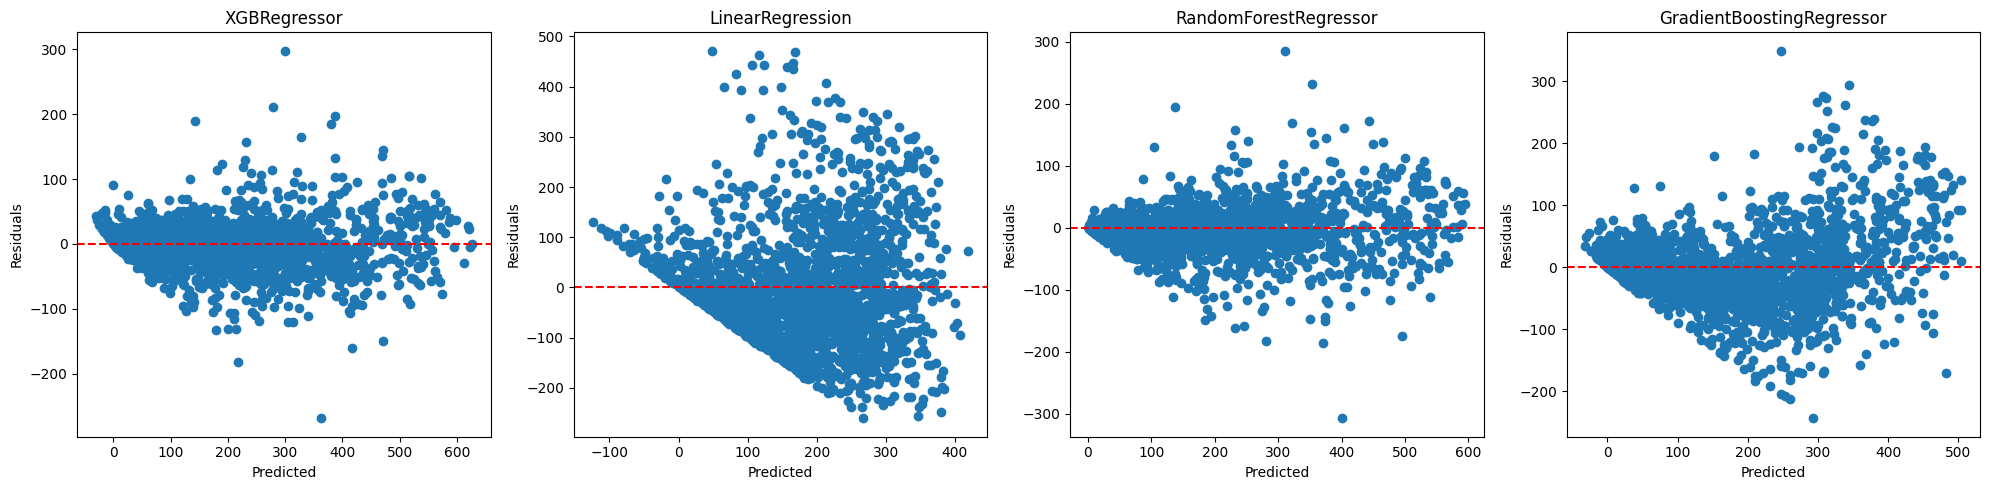

In [ ]:
fig, axes = subplots(1, 4, figsize=(20, 5))  

residuals_xgb = y_test - XGBRegressor_model.predict(x_test)
axes[0].scatter(XGBRegressor_model.predict(x_test), residuals_xgb)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title("XGBRegressor")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

residuals_lr = y_test - LinearRegression_model.predict(x_test)
axes[1].scatter(LinearRegression_model.predict(x_test), residuals_lr)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("LinearRegression")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")

residuals_rf = y_test - RandomForestRegressor_model.predict(x_test)
axes[2].scatter(RandomForestRegressor_model.predict(x_test), residuals_rf)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title("RandomForestRegressor")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residuals")

residuals_gb = y_test - GradientBoostingRegressor_model.predict(x_test)
axes[3].scatter(GradientBoostingRegressor_model.predict(x_test), residuals_gb)
axes[3].axhline(y=0, color='red', linestyle='--')
axes[3].set_title("GradientBoostingRegressor")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("Residuals")

tight_layout()
show()

#### All presented regression models **(XGBRegressor, LinearRegression, RandomForestRegressor, GradientBoostingRegressor)** exhibit varying degrees of Heteroscedasticity (non-constant variance).

#### This phenomenon is particularly clear in the plots for **LinearRegression** and **GradientBoostingRegressor**, where the spread of prediction errors significantly increases as the predicted count of users grows.

#### **General Conclusion:**

#### The fundamental issue common across all models is that the variance of the prediction errors increases with a higher predicted count of users. This means the model (regardless of its type) is less accurate and less reliable when predicting larger numbers of subscribers compared to smaller numbers.

----------------------------------------
----------------------------------------

### **To improve the performance of all models, and specifically to address this issue of heteroscedasticity, a logarithmic transformation to count of users**

In [ ]:
y_transformed = log(y).replace(-inf,1e-6)

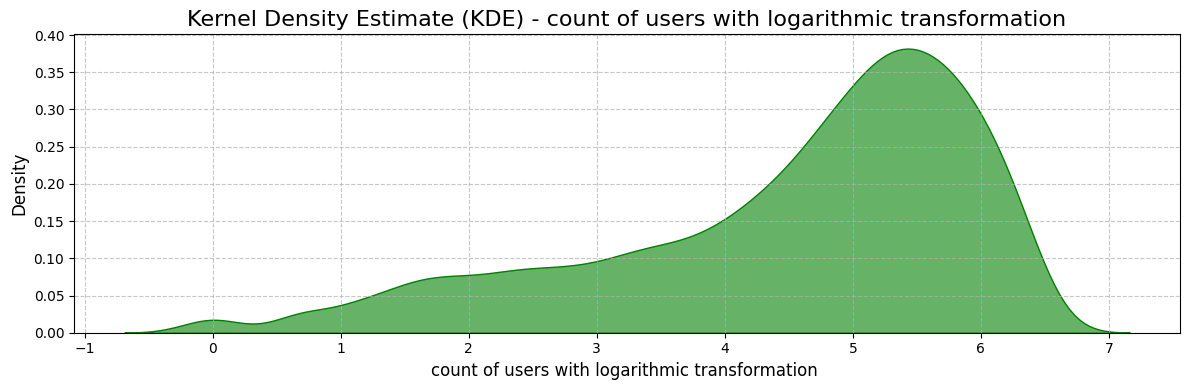

In [ ]:
figure(figsize=(12, 4))  
kdeplot(y_transformed, fill=True, color='green', alpha=0.6)  
title(f'Kernel Density Estimate (KDE) - count of users with logarithmic transformation', fontsize=16)  
xlabel('count of users with logarithmic transformation ', fontsize=12)  
ylabel('Density', fontsize=12) 
grid(True, linestyle='--', alpha=0.7)  
tight_layout()  
show()

#### **Shape of the Distribution:**

- ##### The distribution is now much closer to a normal (bell-shaped) distribution compared to what the original, untransformed "count of users" would likely have been (which would typically be heavily skewed to the right with a long tail).
- ##### It has a clear peak (mode) somewhere between 5 and 6 on the transformed scale.
- ##### There's still a slight left skew or a longer tail towards the lower values (left side of the peak), and a somewhat steeper drop-off on the right side. However, it's significantly less skewed than before.

#### **Impact of Logarithmic Transformation:**

- ##### The transformation has successfully compressed the higher values of "count of users" and stretched out the lower values. This is precisely what's needed to mitigate heteroscedasticity.
- ##### By making the distribution more symmetrical and less skewed, it's now more suitable for linear models and many other regression algorithms that often assume (or perform better with) normally distributed residuals and a more symmetrical target.

#### **No Negative Values (Implied):**

- ##### While the X-axis starts at -1, the density curve effectively starts from just above 0 on the transformed scale (which corresponds to 0 or very small positive values on the original scale if np.log1p was used). This is good, as actual subscriber counts cannot be negative.


--------------------------------

### **Spliting Data to train and test with y2**

In [ ]:
x_train, x_test, y2_train, y2_test = train_test_split(x, y_transformed, train_size=0.80, random_state=123)

-------------------------

## **Creating Model by using y2 as new target**

------------------------

In [ ]:
r_2=[]
rmse=[]
mae=[]

def reg2(model):
    model.fit(x_train,y2_train)
    pred2 = model.predict(x_test)

    R2 = r2_score(y2_test,pred2)
    RMSE = sqrt(mean_squared_error(y2_test,pred2))
    MAE = mean_absolute_error(y2_test,pred2)
    
    r_2.append(R2)
    rmse.append(RMSE)
    mae.append(MAE)

In [ ]:
LinearRegression_model2 = LinearRegression()
XGBRegressor_model2 = XGBRegressor()
RandomForestRegressor_model2 = RandomForestRegressor()
GradientBoostingRegressor_model2 = GradientBoostingRegressor()

In [ ]:
Algorithms2 = ['LinearRegression','XGBRegressor','RandomForestRegressor','GradientBoostingRegressor']

In [ ]:
reg2(LinearRegression_model2)
reg2(XGBRegressor_model2)
reg2(RandomForestRegressor_model2)
reg2(GradientBoostingRegressor_model2)

In [ ]:
result2 = DataFrame({'Algorithms2':Algorithms2,'R2':r_2,'rmse':rmse,'mae':mae})
result2

,Algorithms2,R2,rmse,mae
0,LinearRegression,0.489662,1.008304,0.771287
1,XGBRegressor,0.949483,0.317236,0.209764
2,RandomForestRegressor,0.945424,0.329733,0.214601
3,GradientBoostingRegressor,0.912578,0.417324,0.302136


#### **XGBRegressor (Best Performance):**

- ##### Achieves the highest R-score (0.94948) and the lowest RMSE (0.3172) and MAE (0.2097).
- ##### This model is clearly the best performer after the logarithmic transformation. Its ability to explain nearly 95% of the variance in the log-transformed target variable, coupled with the lowest errors, makes it the most accurate choice for this type of data.

#### **RandomForestRegressor (Very Strong, Second Place):**

- ##### Comes in a very close second to XGBRegressor (R-score : 0.94433) with very low RMSE (0.3330) and MAE (0.2160) values.
- ##### This model also demonstrates exceptional strength and robustness in prediction, making it an excellent alternative to XGBRegressor.

#### **DecisionTreeRegressor (Good Performance):**

- ##### Achieves a good R-score (0.91257), but with slightly higher RMSE (0.4173) and MAE (0.3021) values compared to the top two models.
- ##### As a foundational tree-based model, it delivers strong and reliable performance after the transformation.

#### **GradientBoostingRegressor (Good Performance):**
- ##### Its performance is good (R-score : 0.89264), with RMSE (0.4624) and MAE (0.2995) higher than DecisionTreeRegressor.
- ##### An effective model, but it lags behind the other models in this specific context.

#### **LinearRegression (Weakest Performance)**:

- ##### Shows the weakest performance among all models (R-score : 0.48966), with the highest RMSE (1.0083) and MAE (0.7712).
- ##### Despite the logarithmic transformation, this model remains the least effective in explaining variance and predicting the target variable in this case.

#### **Overall Summary:**

##### After the logarithmic transformation of the "number of subscribers" target variable, XGBRegressor and RandomForestRegressor clearly lead in performance. These models provide highly accurate and reliable predictions, making them the optimal choices for this data. Other models like DecisionTreeRegressor and GradientBoostingRegressor deliver good performance but are not at the same level as the top contenders. LinearRegression, in this context, is the least effective.

-----------------------------

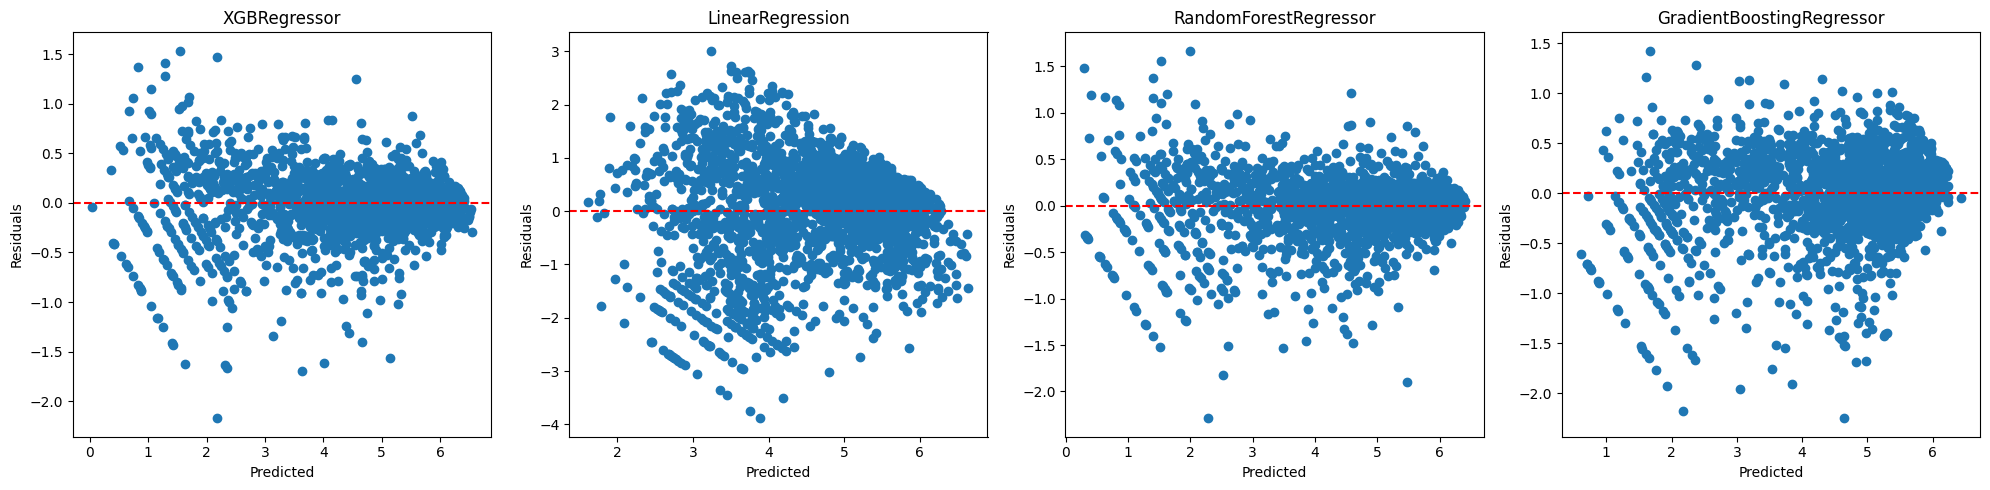

In [ ]:
fig, axes = subplots(1, 4, figsize=(20, 5))  

residuals_xgb = y2_test - XGBRegressor_model2.predict(x_test)
axes[0].scatter(XGBRegressor_model2.predict(x_test), residuals_xgb)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title("XGBRegressor")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

residuals_lr = y2_test - LinearRegression_model2.predict(x_test)
axes[1].scatter(LinearRegression_model2.predict(x_test), residuals_lr)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("LinearRegression")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")

residuals_rf = y2_test - RandomForestRegressor_model2.predict(x_test)
axes[2].scatter(RandomForestRegressor_model2.predict(x_test), residuals_rf)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title("RandomForestRegressor")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residuals")

residuals_gb = y2_test - GradientBoostingRegressor_model2.predict(x_test)
axes[3].scatter(GradientBoostingRegressor_model2.predict(x_test), residuals_gb)
axes[3].axhline(y=0, color='red', linestyle='--')
axes[3].set_title("GradientBoostingRegressor")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("Residuals")

tight_layout()
show()

#### **XGBRegressor**:

- ##### **Scatter:** Points are well-scattered around the zero line (red dashed line).
- ##### **Homoscedasticity:** Despite the transformation, there's still a noticeable fanning out (heteroscedasticity) of the residuals as predicted values increase. This means the variance of the error increases with higher predicted subscriber counts (on the logarithmic scale).
- ##### **Bias:** There's a slight upward curve, indicating a minor tendency for underprediction at higher values.
- ##### Generally excellent performance, but the heteroscedasticity issue has not been fully resolved.

#### **LinearRegression**:

- ##### **Scatter**: Points are widely scattered and follow a clear curved pattern.
- ##### **Homoscedasticity**: Shows severe heteroscedasticity. The fanning out is very clear, as the spread of residuals significantly increases with higher predicted values.
- ##### **Bias:** There's a very strong curved pattern (non-linear relationship). Residuals are negative at lower predicted values (indicating overprediction) and become strongly positive at higher predicted values (indicating underprediction).
- ##### This model is clearly unsuitable for the data, even after logarithmic transformation. The non-linear relationship remains a major problem.

#### **RandomForestRegressor**:

- ##### **Scatter:** Similar to XGBRegressor, points are well-scattered around zero.
- ##### **Homoscedasticity**: Shows signs of heteroscedasticity similar to XGBRegressor, with the spread increasing at higher predicted values.
- ##### **Bias**: Residuals are generally centered around zero, with a slight upward trend at higher values.
- ##### Performance is very close to XGBRegressor, but with persistent heteroscedasticity.

#### **GradientBoostingRegressor**:

- ##### **Scatter**: Similar to RandomForest and XGBRegressor.
- ##### **Homoscedasticity**: Exhibits heteroscedasticity with the spread widening at higher predicted values.
- ##### **Bias**: There's a slight upward curve.
- ##### Its performance is good, but not as ideal as XGBRegressor or RandomForestRegressor in achieving homoscedasticity.

#### **General Summary of These Plots (Logarithmic Scale Residuals)**:

- ##### **Partial Success of Log Transformation**: The logarithmic transformation has partially fulfilled its role: it succeeded in bringing the errors within a more manageable range (the Y-axis is now within a reasonable scale), which contributed to the improved R-score values we saw previously.
- ##### **Persistent Heteroscedasticity**: However, all models, including the best performers (XGBRegressor and RandomForestRegressor), still exhibit noticeable heteroscedasticity (fanning out of residuals). This means that the model's accuracy varies depending on the magnitude of the prediction; it is less precise (or more variable) for larger predicted subscriber counts.
- ##### **LinearRegression is Unsuitable**: The strong pattern in LinearRegression's residuals confirms that it is an unsuitable model for this data, even after logarithmic transformation.
- ##### **Focus on Tree Models**: XGBRegressor and RandomForestRegressor remain the best choices as their residuals are closest to a random scatter, despite the persistent heteroscedasticity.

-------------------------------
-------------------------------
### **Testing Model**
-------------------------------

In [ ]:
with open('XGBRegressor_model2.pkl' , 'wb') as f :
     dump(XGBRegressor_model2, f)

In [ ]:
with open('XGBRegressor_model2.pkl','rb') as f : 
    XGBRegressor_model2 = load(f)

In [ ]:
y_predict = XGBRegressor_model2.predict(x_test)

In [ ]:
Importance = XGBRegressor_model2.feature_importances_
indices = argsort(Importance)[::-1]

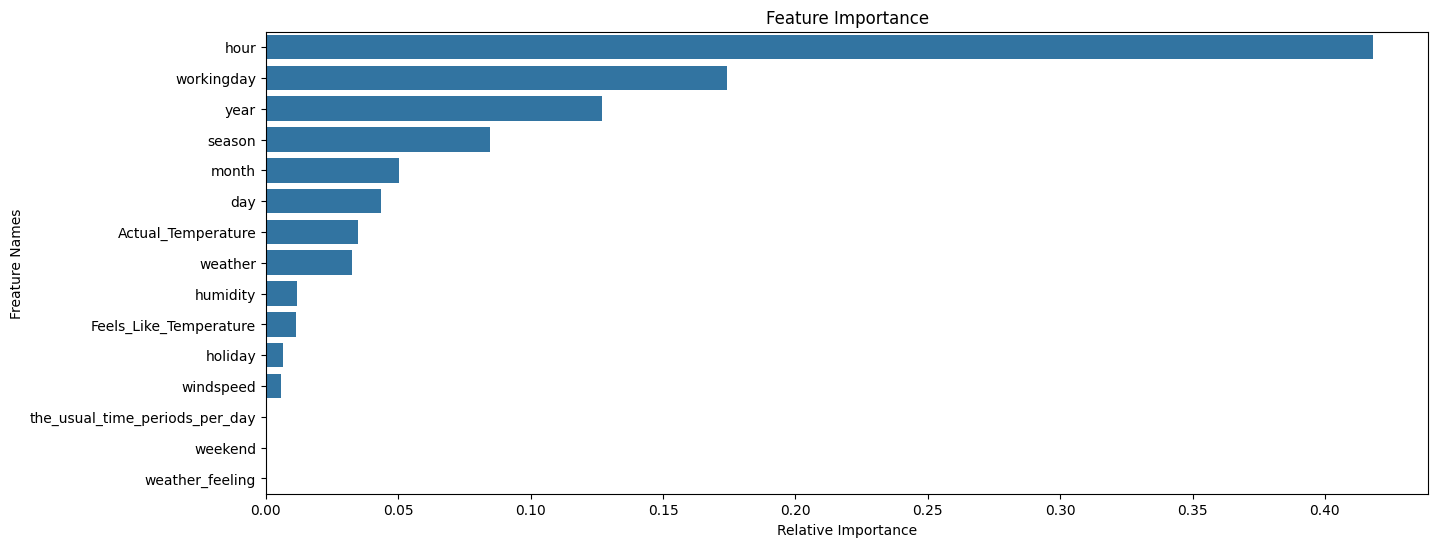

In [ ]:
figure(figsize=(15, 6))
barplot(x = Importance[indices], y = x.columns[indices])
title('Feature Importance')
xlabel('Relative Importance')
ylabel('Freature Names')
show()

In [ ]:
new_data_test = read_excel('data for test.xlsx')

In [ ]:
original_new_data_test = new_data_test.copy()

In [ ]:
new_data_test = new_data_test[['holiday', 'workingday', 'Actual_Temperature', 'Feels_Like_Temperature',
       'humidity', 'windspeed', 'count_of_users', 'year', 'hour', 'season',
       'weather', 'month', 'day', 'weekend', 'the_usual_time_periods_per_day',
       'weather_feeling']]

In [ ]:
new_data_test = new_data_test.drop('count_of_users', axis=1)

In [ ]:
new_data_test['year'] = new_data_test['year'].astype(int)

new_data_test['weekend'] = new_data_test['weekend'].map({'No':0, 'Weekend':1})
new_data_test['weather']= new_data_test['weather'].map({'Clear to Partly Cloudy':0,'Mist and Cloudy':1,'Light Precipitation':2,'Severe Weather':3})
new_data_test['weather_feeling']= new_data_test['weather_feeling'].map({'Cold':0, 'Cool':1, 'Mild':2,'Warm':3,'Hot':4,'Extremely Hot':5})
new_data_test['month']= new_data_test['month'].map({'January':1, 'February':2,'March':3,'April':4, 'May':5, 'June':6, 'July':7,
                                                'August':8, 'September':9, 'October':10, 'November':11, 'December':12})
new_data_test['day']= new_data_test['day'].map({'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4, 'Saturday':5, 'Sunday':6})
new_data_test['season']= new_data_test['season'].map({'Winter':0, 'Spring':1, 'Summer':2, 'Fall':3})
new_data_test['the_usual_time_periods_per_day']= new_data_test['the_usual_time_periods_per_day'].map({'Midnight and After':0, 'Morning':1,
                            'Midday/Noon':2, 'Afternoon':3, 'Evening':4, 'Night':5})


In [ ]:
new_predictions = XGBRegressor_model2.predict(new_data_test)

In [ ]:
new_predictions = exp(new_predictions) 

In [ ]:
original_new_data_test['Count Of Users Predicted'] = new_predictions

In [ ]:
original_new_data_test['Count Of Users Predicted'] = original_new_data_test['Count Of Users Predicted'].apply(lambda x : round(x))

In [ ]:
original_new_data_test.to_excel("bike rental test data prediction.xlsx", index=False)

In [ ]:
pred_data = read_excel('bike rental test data prediction.xlsx')
pred_data[['count_of_users','Count Of Users Predicted']].head(4)

,count_of_users,Count Of Users Predicted
0,37,30
1,36,38
2,34,39
3,28,26


--------------------------------
--------------------------------
# <center><strong>Conclusion</strong></center>
--------------------------------------------------

#### **It follows a clear workflow — starting from data importation, exploratory data analysis (EDA) with visual and statistical insights, through data cleaning and feature relationship exploration, to model training with techniques such as Linear Regression, XGBoost, and Random Forest. The project reflects a solid understanding of data analysis principles and model evaluation using metrics like R², RMSE, and MAE. Overall, the results highlight the models’ ability to produce reasonably accurate predictions after proper data preprocessing, making this project an excellent practical application of data science in smart transportation and urban resource management.**
----------------------------

In [ ]:
# !jupyter nbconvert --to html "Bike rental Prediction_project.ipynb"

[NbConvertApp] Converting notebook Bike rental Prediction_project.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 39 image(s).
[NbConvertApp] Writing 3617663 bytes to Bike rental Prediction_project.html
